# Assignment 3 - KNN Classifiers

The goal of this assignment is to apply the K-Nearest Neighbors (KNN) classification algorithm on the digits dataset, which contains images of hand-written digits.

The dataset comprises 8x8 pixel images of hand-written digits (0 through 9). Each image is represented as a 64-dimensional vector, where each dimension corresponds to a pixel's grayscale value.

## Tasks:

### 1. Data Loading and Exploration: (2 points)

Data shape: (1797, 64)
Target shape: (1797,)


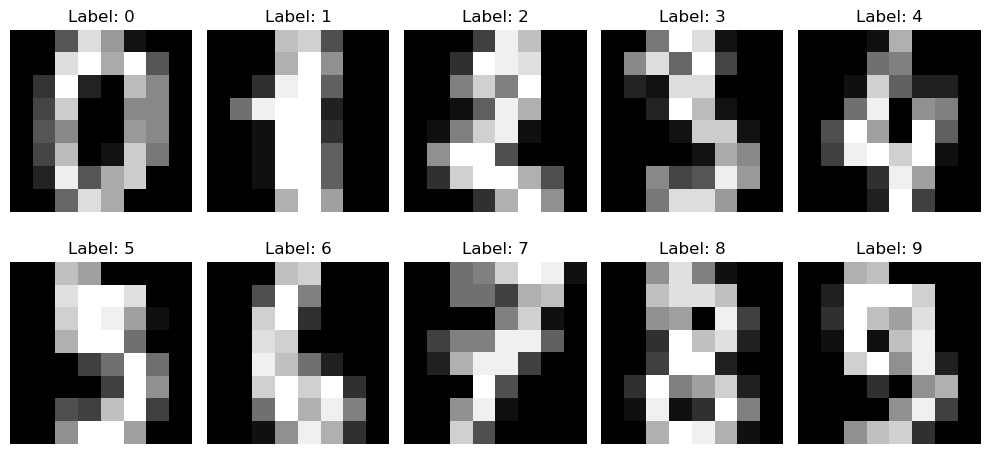

In [7]:
# Import necessary libraries
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# Load the dataset
digits = load_digits()

# Explore the dataset
print(f"Data shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")

# Visualize the first few images and their labels
"""
Question: Visualize the Digits Dataset (2 points)
Display the first ten images from the digits dataset with their labels. Use a 2x5 grid of subplots, and ensure the grid size is 10x5. Show each image in grayscale and title it with the respective label. Adjust the layout to prevent overlap.

Hints:

Use the 'ax.imshow()' method to display an image and 'ax.set_title()' to set its title.
Write your code below:
"""
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    # show image 
    ax.imshow(image, cmap='grey')
    # set the image title with the label
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### 2. Data Preprocessing (2 points)

In [19]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
"""
Question: Dataset Splitting (2 points)
Using the digits dataset, divide it into training and testing sets. 

Hints:

Utilize the train_test_split function.
Remember to set test_size and random_state.
"""
train_data, test_data, train_target, test_target = train_test_split(digits.data, digits.target, test_size=0.3, random_state=25)
# write the train and test split
print(f"training digits data shape : {train_data.shape}")
print(f"testing digits data shape : {test_data.shape}")
print(f"training digits target shape :{train_target.shape}")
print(f"testing digits target shape : {test_target.shape}")

training digits data shape : (1257, 64)
testing digits data shape : (540, 64)
training digits target shape :(1257,)
testing digits target shape : (540,)


### 3. KNN Classification (2 points)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)

# Train the classifier and predict labels for the test set
"""
Question: KNN Classifier Training and Prediction (2 points)
Given the initialized KNN classifier with n_neighbors set to 5, perform the following tasks:

1- Train the classifier using the training data.
2- Predict the labels for the test dataset using the trained classifier.

Hints:

Use the 'fit' method to train the classifier.
Utilize the 'predict' method to make predictions on the test data.
"""
# fit the model
knn.fit(train_data, train_target)
# predict X_test and store it in y_pred
y_pred = knn.predict(test_data)
y_pred

array([4, 0, 2, 4, 0, 3, 7, 2, 3, 1, 7, 4, 3, 6, 7, 9, 3, 9, 9, 7, 2, 9,
       8, 6, 7, 5, 5, 9, 2, 0, 7, 4, 6, 1, 4, 6, 3, 9, 0, 8, 5, 7, 7, 6,
       4, 2, 1, 3, 1, 4, 2, 0, 4, 2, 4, 2, 4, 1, 5, 4, 0, 9, 6, 0, 0, 8,
       6, 1, 9, 5, 1, 5, 3, 4, 1, 2, 7, 1, 9, 6, 3, 5, 7, 5, 5, 6, 5, 4,
       3, 1, 1, 3, 5, 5, 9, 8, 0, 7, 8, 5, 9, 4, 6, 5, 4, 9, 4, 3, 7, 0,
       7, 9, 7, 3, 5, 3, 8, 0, 1, 4, 9, 5, 6, 7, 1, 8, 5, 3, 8, 9, 7, 3,
       7, 8, 3, 8, 6, 6, 7, 0, 6, 2, 3, 4, 0, 2, 0, 3, 0, 1, 0, 3, 7, 6,
       7, 3, 6, 9, 4, 0, 8, 4, 1, 1, 6, 4, 4, 3, 8, 5, 3, 8, 7, 7, 9, 1,
       7, 9, 7, 6, 8, 3, 8, 5, 1, 8, 1, 1, 3, 1, 9, 0, 8, 8, 5, 2, 8, 1,
       0, 6, 7, 1, 7, 6, 0, 2, 5, 0, 7, 7, 2, 8, 1, 5, 6, 8, 0, 0, 6, 3,
       2, 9, 2, 4, 6, 2, 4, 3, 8, 3, 6, 1, 5, 0, 5, 3, 3, 9, 6, 6, 2, 6,
       1, 0, 4, 0, 1, 9, 9, 5, 6, 3, 6, 9, 1, 2, 9, 5, 5, 9, 7, 5, 3, 6,
       0, 4, 5, 4, 6, 1, 8, 7, 7, 3, 8, 0, 4, 2, 9, 4, 2, 2, 1, 6, 3, 5,
       4, 2, 8, 4, 8, 2, 4, 9, 0, 0, 3, 0, 1, 1, 4,

### 4. Evaluation (2 points)

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix

"""
Question: Evaluating Classifier Performance (2 points)
After obtaining the predicted labels from the trained KNN classifier, evaluate its performance using the following metrics:

Calculate the accuracy of the classifier and display it in percentage format.
Compute the confusion matrix for the true labels and predicted labels.
Hints:

Use the accuracy_score function to get the accuracy.
The confusion_matrix function can help in deriving the confusion matrix.
"""
# Calculate accuracy
accuracy = accuracy_score(test_target, y_pred)
print(f"Accuracy with k=5: {accuracy*100:.2f}%")

# Confusion matrix
conf_mat = confusion_matrix(test_target, y_pred)
print("Confusion Matrix:")
print(conf_mat)

Accuracy with k=5: 99.07%
Confusion Matrix:
[[56  0  0  0  0  0  0  0  0  0]
 [ 0 55  0  0  0  0  0  0  0  0]
 [ 0  0 46  0  0  0  0  0  0  0]
 [ 0  0  0 55  0  0  0  0  0  0]
 [ 0  0  0  0 61  0  0  0  0  0]
 [ 0  0  0  0  0 57  0  0  0  0]
 [ 0  0  0  0  0  0 52  0  1  0]
 [ 0  0  0  0  0  0  0 51  0  0]
 [ 0  1  0  0  0  0  0  0 52  0]
 [ 0  0  0  1  1  0  0  0  1 50]]


### 5. Experimenting with different k values (2 points)

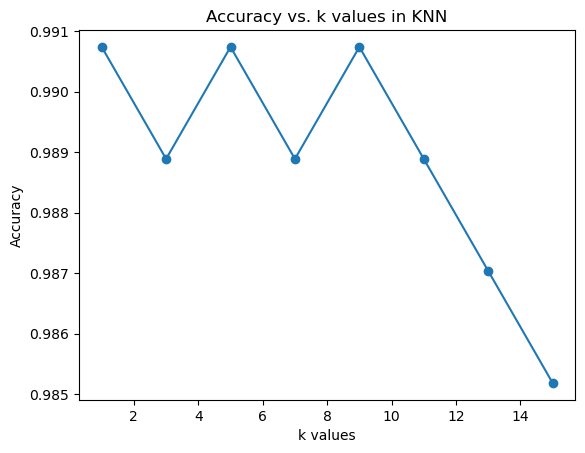

In [25]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
accuracies = []

"""
Question: Experimenting with Different k-values in KNN (2 points)
The k-value in KNN determines the number of neighbors to consider when making a prediction. To find an optimal k-value, perform the following:

Iterate over different k-values given in the k_values list.
For each k-value, train the KNN classifier and predict the labels for the test set.
Calculate and store the accuracy for each k-value in the accuracies list.
Finally, plot a graph of accuracy vs. k-values to visualize the performance of the KNN classifier for different k-values.

Hint:

Use a loop to iterate over each k-value.
Remember to initialize the KNN classifier with the current k-value in each iteration
"""
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_data, train_target)
    y_pred = knn.predict(test_data)
    accuracy = accuracy_score(test_target, y_pred)
    accuracies.append(accuracy)
    # add the accuracy to accuracies

# Plot the results
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k values")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. k values in KNN")
plt.show()